In [22]:
import pandas as pd
from faker import Faker
import random

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fake = Faker()
random.seed(42)  # Para reproducibilidad

In [23]:
df_usuarios = pd.read_csv("usuarios.csv", encoding="utf-8-sig", parse_dates=["fecha_registro"])
df_usuarios.head(5)
# print(df_usuarios.columns)
# print(df_usuarios.info())

,id_usuario,nombre,email,fecha_registro
0,1,Apolonia Bou Alcolea,ubarroso@example.com,2026-08-09
1,2,Hernán Lara Tejedor,saezjavi@example.org,2026-06-28
2,3,Eva Dávila Castelló,eufemia17@example.org,2026-06-27
3,4,Milagros Roig Iñiguez,uarco@example.net,2026-06-23
4,5,Benita Herrera Menendez,castrillomarcio@example.org,2026-06-20


In [24]:
df_posts = pd.read_csv("posts.csv", encoding="utf-8-sig", parse_dates=["fecha_publicacion"])
# df_posts.head(5)


In [25]:
post_aleatorio = df_posts.sample(n=1).iloc[0]
print(post_aleatorio["fecha_publicacion"])
fecha_interaccion = fake.date_between(start_date=post_aleatorio["fecha_publicacion"], end_date='today')

2026-06-19 00:00:00


Creamos a continuacion una tabla para representar las interacciones entre posts y usuarios.


In [26]:
def generate_interactions(df_posts, df_usuarios, number_of_interactions):
    tipo_interacciones = ["like", "comentario", "compartir", "vista"]
    interacciones = []

    for i in range(number_of_interactions):
        post_aleatorio = df_posts.sample(n=1).iloc[0]    
        usuario_aleatorio = df_usuarios.sample(n=1).iloc[0]
        fecha_interaccion = fake.date_between(start_date=post_aleatorio["fecha_publicacion"], end_date='today')

        interaccion = {
            "id_interaccion": i + 1,
            "id_post": post_aleatorio["id_post"], 
            "id_usuario": usuario_aleatorio["id_usuario"],
            "tipo_interaccion": random.choice(tipo_interacciones),
            "fecha_interaccion": fecha_interaccion
        }
        interacciones.append(interaccion)
    return pd.DataFrame(interacciones)

In [27]:
interacciones_df = generate_interactions(df_posts, df_usuarios, 6000)
interacciones_df.head(10)

# Guardamos el DataFrame de interacciones en un archivo CSV
interacciones_df.to_csv("interacciones.csv", index=False, encoding="utf-8-sig")

In [28]:
# Publicaciones por dia
posts_por_dia = df_posts.groupby("fecha_publicacion").size()
# plt.hist(df_posts.groupby("fecha_publicacion").size())
posts_por_dia.tail(5)


fecha_publicacion
2026-08-07    31
2026-08-08    21
2026-08-09    25
2026-08-10    25
2026-08-11    24
dtype: int64

(array([20619., 20626., 20635., 20642., 20649., 20656., 20666., 20673.]),
 [Text(20619.0, 0, '2026-06-15'),
  Text(20626.0, 0, '2026-06-22'),
  Text(20635.0, 0, '2026-07-01'),
  Text(20642.0, 0, '2026-07-08'),
  Text(20649.0, 0, '2026-07-15'),
  Text(20656.0, 0, '2026-07-22'),
  Text(20666.0, 0, '2026-08-01'),
  Text(20673.0, 0, '2026-08-08')])

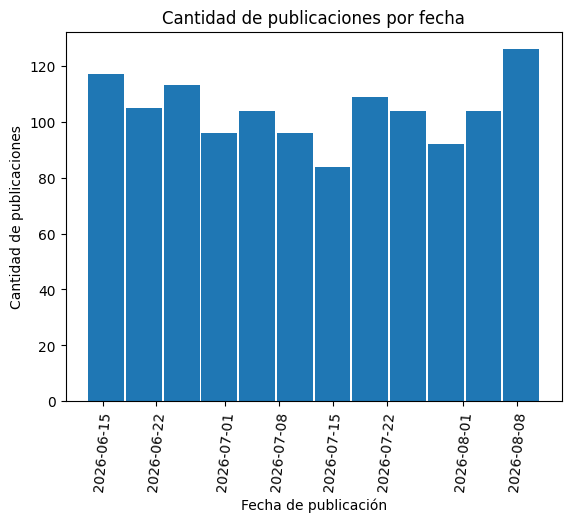

In [29]:
# Histograma de frecuencia de publicaciones por fecha
plt.figure()
plt.hist(df_posts["fecha_publicacion"], bins=12, orientation='vertical', rwidth=0.95)
plt.title("Cantidad de publicaciones por fecha")
plt.xlabel("Fecha de publicación")
plt.ylabel("Cantidad de publicaciones")
plt.xticks(rotation=85)

In [30]:
# Calculo de Engagement Rate para todos los posts, y por dia
conteo_por_tipo = interacciones_df.groupby('tipo_interaccion').size()
engagement_rate_completo = (conteo_por_tipo["like"] + conteo_por_tipo["comentario"]) / len(df_posts)
print(f"Engagement Rate periodo completo: {engagement_rate_completo.round(3)}")

Engagement Rate periodo completo: 2.374


In [31]:
# Calculo de Engagement Rate por dia
interacciones_df['es_engagement'] = interacciones_df['tipo_interaccion'].isin(['like', 'comentario'])

# 2. Agrupamos por fecha y con .agg aplicamos las funciones de agregación necesarias
df_diario = interacciones_df.groupby('fecha_interaccion').agg(
    likes_y_comentarios=('es_engagement', 'sum'),
    total_posts=('id_post', 'nunique') # o el total de posts publicados ese día según tu tabla de posts
).reset_index()

# 3. Calculamos la métrica final por fila
df_diario['engagement_rate'] = df_diario['likes_y_comentarios'] / df_diario['total_posts']       
# df_diario.head(10)

df_diario.sort_values('engagement_rate', ascending=False).head(10)

,fecha_interaccion,likes_y_comentarios,total_posts,engagement_rate
7,2026-06-20,16,18,0.888889
58,2026-08-10,218,251,0.868526
59,2026-08-11,238,293,0.812287
57,2026-08-09,176,261,0.674330
21,2026-07-04,33,49,0.673469
44,2026-07-27,65,97,0.670103
29,2026-07-12,49,76,0.644737
3,2026-06-16,5,8,0.625000
15,2026-06-28,19,31,0.612903
53,2026-08-05,118,193,0.611399


Calculo de Usuarios activos por día (DAU - Daily Active Users) y usuarios nuevos.

In [32]:
# Calculo de usuarios nuevos por dia
df_usuarios_nuevos = df_usuarios.groupby("fecha_registro").agg(
    usuarios_nuevos=("id_usuario","nunique")).reset_index()
df_usuarios_nuevos.head(10)

,fecha_registro,usuarios_nuevos
0,2026-06-13,5
1,2026-06-14,2
2,2026-06-15,6
3,2026-06-16,11
4,2026-06-17,11
5,2026-06-18,4
6,2026-06-19,5
7,2026-06-20,8
8,2026-06-21,5
9,2026-06-22,8


In [33]:
df_dau = interacciones_df.groupby("fecha_interaccion").agg(
    usuarios_activos=("id_usuario","nunique")).reset_index()
df_dau.sort_values("usuarios_activos", ascending=False).head()
# df_dau.head(10)

,fecha_interaccion,usuarios_activos
59,2026-08-11,272
58,2026-08-10,233
57,2026-08-09,204
56,2026-08-08,195
55,2026-08-07,178


/tmp/ipykernel_970369/3555388459.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df_30d = df_dau[df_dau["fecha_interaccion"] >= (fecha_max - pd.Timedelta(days=30))]


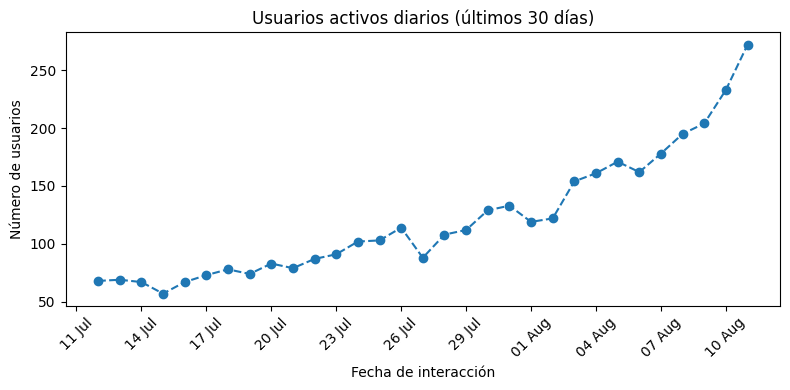

In [34]:
fecha_max = df_dau["fecha_interaccion"].max()
df_30d = df_dau[df_dau["fecha_interaccion"] >= (fecha_max - pd.Timedelta(days=30))]


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_30d["fecha_interaccion"], df_30d["usuarios_activos"], '--', marker='o', )

# 1. Definir el formato compacto (Ej: "01 Aug" o "01/08")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# 2. Controlar la frecuencia de los ticks (Ej: una marca cada 3 días para que no se sature)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Rotar un poco para mejor lectura
plt.title("Usuarios activos diarios (últimos 30 días)")
plt.xlabel("Fecha de interacción")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45)  # Al ser tan compacto, incluso podés dejarlo en 0° (horizontal)
plt.tight_layout()
plt.show()

Top 10 de usuarios más activos. Agregamos al data frame columnas con el numero de likes, comentarios, vistas y compartidos por usuario.
El criterio será darle mayor peso a los posteos y a los comentarios, y menos a los likes y compartidas.

In [35]:
posts_por_usuario = df_posts.groupby("id_usuario").agg(
    total_posts=("id_post","count")).reset_index()

top_interacciones = interacciones_df.groupby("id_usuario").agg(
    total_interacciones=("id_interaccion", "count"),
    likes=("tipo_interaccion", lambda x: (x=="like").sum()),
    comentarios=("tipo_interaccion", lambda x: (x=="comentario").sum()),
    compartir=("tipo_interaccion", lambda x: (x=="compartir").sum()),
    vistas=("tipo_interaccion", lambda x: (x=="vista").sum())
).reset_index()

top_completo = pd.merge(top_interacciones, posts_por_usuario, on="id_usuario", how="outer").fillna(0).astype(int)
top_completo["Score"] = (
    top_completo["total_posts"] * 3
    + top_completo["comentarios"] * 2
    + top_completo["likes"] 
    + top_completo["compartir"] 
    + top_completo["vistas"]
)

# top_completo = pd.merge(top_completo, df_usuarios[["id_usuario", "nombre", "email"]], on="id_usuario", how="left")

top_10 = top_completo.sort_values("Score", ascending=False).head(10)

# posts_por_usuario.head()
# top_interacciones.head()
top_completo.head()
# top_10.head(5)

,id_usuario,total_interacciones,likes,comentarios,compartir,vistas,total_posts,Score
0,1,17,6,5,6,0,10,52
1,2,19,6,4,6,3,13,62
2,3,13,5,2,4,2,7,36
3,4,16,2,5,3,6,11,54
4,5,13,2,4,4,3,17,68


In [36]:
top_10_con_datos_usuarios = pd.merge(top_10, df_usuarios, on="id_usuario", how="left")

# Guardamos el DataFrame de top 10 usuarios en un archivo CSV
top_10_con_datos_usuarios.to_csv("top_10_usuarios.csv", index=False, encoding="utf-8-sig")

In [37]:
top_10_con_datos_usuarios.head()

,id_usuario,total_interacciones,likes,comentarios,compartir,vistas,total_posts,Score,nombre,email,fecha_registro
0,48,22,3,8,6,5,21,93,Sandra de Monreal,npereira@example.org,2026-06-13
1,82,11,3,3,3,2,25,89,Natanael Danilo Ramírez Fajardo,clarajimenez@example.org,2026-06-25
2,69,25,8,8,3,6,18,87,Santiago Luís Bustos Benavides,montalbanjuan-jose@example.com,2026-06-15
3,83,13,5,3,2,3,23,85,Graciela Hierro,uportillo@example.net,2026-07-27
4,61,19,6,4,8,1,20,83,Anastasio Quintana Ramis,smarti@example.org,2026-06-13
